# Hospital Readmission Fairness Audit

## Notebook 02 - Baseline Models, Explainability & Fairness Metrics

## Section 3 - Baseline Models & Explainability

In [1]:
!pip -q install ucimlrepo fairlearn shap


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: D:\ondrej_koz\program_files\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the cleaned data from Notebook 01; rebuild it if it is missing.
try:
    df = pd.read_csv('diabetic_clean.csv')
except FileNotFoundError:
    from ucimlrepo import fetch_ucirepo
    ds = fetch_ucirepo(id=296)
    df = pd.concat([ds.data.features, ds.data.targets], axis=1).replace('?', np.nan)
    df = df[df['readmitted'] != '>30'].copy()
    df['readmit_30'] = (df['readmitted'] == '<30').astype(int)

print('Data loaded:', df.shape)

Data loaded: (66221, 49)


### 3.1 Preprocessing

In [3]:
df = df[df['gender'] != 'Unknown/Invalid'].copy()
df = df.dropna(subset=['race']).reset_index(drop=True)

def age_bin(a):
    young = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)']
    mid = ['[60-70)', '[70-80)']
    return 'Under 60' if a in young else ('60-80' if a in mid else '80+')

df['age_group'] = df['age'].apply(age_bin)

num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
            'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
cat_cols = ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id',
            'admission_source_id', 'payer_code', 'max_glu_serum', 'A1Cresult',
            'metformin', 'insulin', 'change', 'diabetesMed']

X_df = df[num_cols + cat_cols].copy()
X_df[num_cols] = X_df[num_cols].fillna(X_df[num_cols].median())
for col in cat_cols:
    X_df[col] = X_df[col].fillna('None').astype(str)

X = pd.get_dummies(X_df, columns=cat_cols)
y = df['readmit_30'].values
print('Feature matrix after one-hot encoding:', X.shape)

Feature matrix after one-hot encoding: (64485, 113)


In [4]:
from sklearn.model_selection import train_test_split

# Stratify the split by race so every group keeps its proportions in train and test.
idx = np.arange(len(df))
Xtr, Xte, ytr, yte, itr, ite = train_test_split(
    X, y, idx, test_size=0.25, random_state=42, stratify=df['race'])

# Sensitive attributes aligned to the TEST set, for the fairness analysis.
sens = df.iloc[ite][['race', 'gender', 'age_group']].reset_index(drop=True)
print('Train:', Xtr.shape, '  Test:', Xte.shape)

Train: (48363, 113)   Test: (16122, 113)


### 3.2 Train the models and report overall performance

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xte_s = scaler.transform(Xte)

logreg = LogisticRegression(max_iter=2000, class_weight='balanced')
logreg.fit(Xtr_s, ytr)

rf = RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced',
                            random_state=42, n_jobs=-1)
rf.fit(Xtr, ytr)
print('Both models trained.')

Both models trained.


In [6]:
from sklearn.metrics import accuracy_score, roc_auc_score

lr_pred = logreg.predict(Xte_s)
lr_prob = logreg.predict_proba(Xte_s)[:, 1]
rf_pred = rf.predict(Xte)
rf_prob = rf.predict_proba(Xte)[:, 1]

for name, pred, prob in [('Logistic Regression', lr_pred, lr_prob),
                         ('Random Forest', rf_pred, rf_prob)]:
    print('%-22s accuracy=%.3f  AUC=%.3f' % (
        name, accuracy_score(yte, pred), roc_auc_score(yte, prob)))

Logistic Regression    accuracy=0.704  AUC=0.720
Random Forest          accuracy=0.722  AUC=0.723


### 3.3 Per-group performance (Random Forest)

In [7]:
from fairlearn.metrics import (MetricFrame, false_negative_rate,
                               false_positive_rate, selection_rate)
from sklearn.metrics import accuracy_score

metrics = {'accuracy': accuracy_score, 'selection_rate': selection_rate,
           'FNR': false_negative_rate, 'FPR': false_positive_rate}

for sf in ['race', 'gender', 'age_group']:
    mf = MetricFrame(metrics=metrics, y_true=yte, y_pred=rf_pred,
                     sensitive_features=sens[sf])
    print('=== Random Forest performance by', sf, '===')
    print(mf.by_group.round(3))
    print()

=== Random Forest performance by race ===
                 accuracy  selection_rate    FNR    FPR
race                                                   
AfricanAmerican     0.741           0.277  0.450  0.217
Asian               0.842           0.183  0.421  0.109
Caucasian           0.713           0.308  0.441  0.253
Hispanic            0.774           0.203  0.569  0.158
Other               0.777           0.208  0.548  0.161

=== Random Forest performance by gender ===
        accuracy  selection_rate    FNR    FPR
gender                                        
Female     0.711           0.317  0.422  0.258
Male       0.734           0.273  0.477  0.223

=== Random Forest performance by age_group ===
           accuracy  selection_rate    FNR    FPR
age_group                                        
60-80         0.697           0.323  0.447  0.270
80+           0.640           0.387  0.433  0.343
Under 60      0.806           0.208  0.456  0.146



### 3.4 Explainability - whitebox vs blackbox

*discharge_disposition_id_11 = "expired"; the large negative LR coefficient is label leakage, not a clinical signal.*

Top 10 features INCREASING 30-day readmission risk:
discharge_disposition_id_1     0.082
discharge_disposition_id_18    0.085
discharge_disposition_id_2     0.103
discharge_disposition_id_5     0.134
number_diagnoses               0.137
discharge_disposition_id_6     0.138
discharge_disposition_id_3     0.164
number_emergency               0.187
discharge_disposition_id_22    0.217
number_inpatient               0.575
dtype: float64

Top 10 features DECREASING readmission risk:
discharge_disposition_id_11   -1.333
admission_type_id_7           -0.131
discharge_disposition_id_13   -0.106
discharge_disposition_id_19   -0.098
discharge_disposition_id_17   -0.090
discharge_disposition_id_14   -0.084
admission_source_id_17        -0.075
diabetesMed_No                -0.075
admission_source_id_10        -0.073
payer_code_BC                 -0.065
dtype: float64


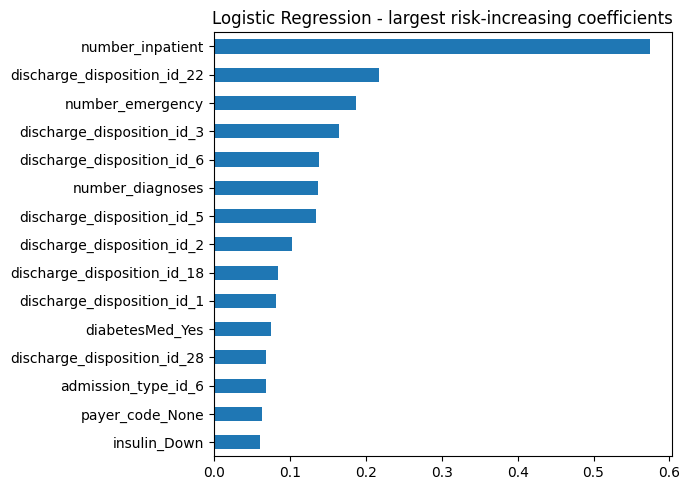

In [8]:
# Whitebox: read the Logistic Regression coefficients directly.
coef = pd.Series(logreg.coef_[0], index=X.columns).sort_values()
print('Top 10 features INCREASING 30-day readmission risk:')
print(coef.tail(10).round(3))
print()
print('Top 10 features DECREASING readmission risk:')
print(coef.head(10).round(3))

coef.tail(15).plot(kind='barh', figsize=(7, 5),
                   title='Logistic Regression - largest risk-increasing coefficients')
plt.tight_layout()
plt.show()

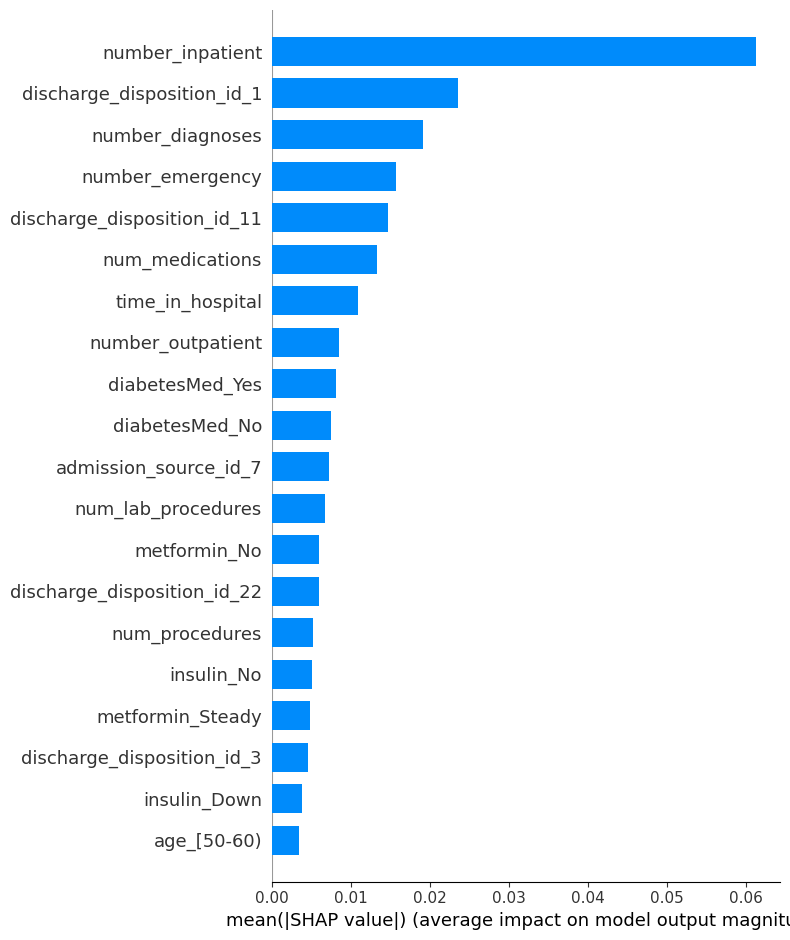

In [9]:
# Blackbox: explain the Random Forest with SHAP (sampled for speed).
import shap

sample = Xte.sample(min(500, len(Xte)), random_state=0)
explainer = shap.TreeExplainer(rf)
sv = explainer.shap_values(sample)

# Different SHAP versions return the positive class differently; handle both.
if isinstance(sv, list):
    sv_pos = sv[1]
elif getattr(sv, 'ndim', 2) == 3:
    sv_pos = sv[:, :, 1]
else:
    sv_pos = sv

shap.summary_plot(sv_pos, sample, plot_type='bar', show=True)

## Section 4 - Fairness Metrics on the Baseline

In [10]:
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

rows = []
for name, pred in [('LogReg', lr_pred), ('RandomForest', rf_pred)]:
    for sf in ['race', 'gender', 'age_group']:
        rows.append({
            'model': name, 'attribute': sf,
            'demographic_parity_diff': demographic_parity_difference(
                yte, pred, sensitive_features=sens[sf]),
            'equalized_odds_diff': equalized_odds_difference(
                yte, pred, sensitive_features=sens[sf])})
print('Fairness gaps (0 = perfectly fair; larger = more unfair):')
print(pd.DataFrame(rows).round(3))

Fairness gaps (0 = perfectly fair; larger = more unfair):
          model  attribute  demographic_parity_diff  equalized_odds_diff
0        LogReg       race                    0.166                0.298
1        LogReg     gender                    0.030                0.065
2        LogReg  age_group                    0.206                0.221
3  RandomForest       race                    0.124                0.148
4  RandomForest     gender                    0.044                0.055
5  RandomForest  age_group                    0.179                0.197


In [11]:
# Equal opportunity: false negative rate per racial group - the priority metric.
for name, pred in [('Logistic Regression', lr_pred), ('Random Forest', rf_pred)]:
    mf = MetricFrame(metrics={'FNR': false_negative_rate}, y_true=yte,
                     y_pred=pred, sensitive_features=sens['race'])
    print(name, '- False Negative Rate by race:')
    print(mf.by_group.round(3))
    print('  FNR gap (worst - best): %.3f' % mf.difference()['FNR'])
    print()

Logistic Regression - False Negative Rate by race:
                   FNR
race                  
AfricanAmerican  0.386
Asian            0.684
Caucasian        0.403
Hispanic         0.621
Other            0.643
  FNR gap (worst - best): 0.298

Random Forest - False Negative Rate by race:
                   FNR
race                  
AfricanAmerican  0.450
Asian            0.421
Caucasian        0.441
Hispanic         0.569
Other            0.548
  FNR gap (worst - best): 0.148



In [12]:
# Calibration: does a predicted probability mean the same thing per group?
def calibration_by_group(prob, y_true, group):
    out = []
    for g in pd.unique(group):
        mask = (group == g)
        out.append({'group': g, 'n': int(mask.sum()),
                    'mean_predicted_prob': prob[mask].mean(),
                    'actual_readmit_rate': y_true[mask].mean()})
    return pd.DataFrame(out)

print('Random Forest calibration by race')
print('(similar predicted-vs-actual gap ACROSS groups = calibration is equal;')
print(' a large gap in absolute terms = the model is poorly calibrated overall):')
print(calibration_by_group(rf_prob, yte, sens['race'].values).round(3))

Random Forest calibration by race
(similar predicted-vs-actual gap ACROSS groups = calibration is equal;
 a large gap in absolute terms = the model is poorly calibrated overall):
             group      n  mean_predicted_prob  actual_readmit_rate
0  AfricanAmerican   3144                0.427                0.180
1        Caucasian  12244                0.440                0.179
2         Hispanic    349                0.393                0.166
3            Asian    120                0.393                0.158
4            Other    265                0.404                0.158
